# 


Customer & Marketing Analytics

An end-to-end customer analytics project combining SQL, Python,
statistical analysis, machine learning, and Power BI.

## Objectives

- Segment customers using RFM analysis
- Analyze customer retention through cohort analysis
- Identify behavioral factors associated with customer churn
- Build a time-based churn prediction model
- Analyze marketing campaign response
- Identify factors associated with campaign response
- Build a campaign response prediction model
- Translate analytical results into business insights

## Datasets

This project uses two independent public datasets:

1. **UCI Online Retail II**
   - Transaction-level retail data
   - Used for RFM, cohort retention, customer behavior, churn analysis,
     and churn prediction

2. **Customer Personality Analysis**
   - Customer-level marketing data
   - Used for campaign response analysis, statistical testing,
     segmentation, and campaign response prediction

The datasets represent separate analytical populations and are not
joined as if they belonged to the same company.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve().parent
RESULTS_DIR = PROJECT_ROOT / "results"
POWERBI_DIR = PROJECT_ROOT / "powerbi"

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Project root:", PROJECT_ROOT)
print("Results directory:", RESULTS_DIR)

Project root: C:\Users\Arun Kumar\OneDrive\Desktop\customer-marketing-analytics
Results directory: C:\Users\Arun Kumar\OneDrive\Desktop\customer-marketing-analytics\results


## 2. Setup & Analytical Results

The SQL and Python pipeline generates reusable analytical result files
under `results/`. The notebook uses these outputs for reporting and
visualization rather than duplicating the transformation logic already
implemented in PostgreSQL.

In [2]:
result_files = sorted(RESULTS_DIR.glob("*.csv"))

print(f"Result files available: {len(result_files)}")
for file in result_files:
    print(" -", file.name)

Result files available: 22
 - campaign_categorical_tests.csv
 - campaign_logistic_regression_confusion_matrix.csv
 - campaign_logistic_regression_feature_importance.csv
 - campaign_model_metrics.csv
 - campaign_numeric_tests.csv
 - campaign_random_forest_confusion_matrix.csv
 - campaign_random_forest_feature_importance.csv
 - campaign_response_by_education.csv
 - campaign_response_by_value.csv
 - chronological_churn_model_metrics.csv
 - churn_model_metrics.csv
 - churn_statistical_tests.csv
 - logistic_regression_chronological_confusion_matrix.csv
 - logistic_regression_chronological_feature_importance.csv
 - logistic_regression_confusion_matrix.csv
 - logistic_regression_feature_importance.csv
 - random_forest_chronological_confusion_matrix.csv
 - random_forest_chronological_feature_importance.csv
 - random_forest_confusion_matrix.csv
 - random_forest_feature_importance.csv
 - significant_campaign_features.csv
 - significant_churn_features.csv


In [3]:
churn_stats = pd.read_csv(
    RESULTS_DIR / "churn_statistical_tests.csv"
)

campaign_numeric_stats = pd.read_csv(
    RESULTS_DIR / "campaign_numeric_tests.csv"
)

campaign_categorical_stats = pd.read_csv(
    RESULTS_DIR / "campaign_categorical_tests.csv"
)

churn_model_metrics = pd.read_csv(
    RESULTS_DIR / "churn_model_metrics.csv"
)

campaign_model_metrics = pd.read_csv(
    RESULTS_DIR / "campaign_model_metrics.csv"
)

print("Churn statistical tests:", churn_stats.shape)
print("Campaign numeric tests:", campaign_numeric_stats.shape)
print("Campaign categorical tests:", campaign_categorical_stats.shape)
print("Churn model metrics:", churn_model_metrics.shape)
print("Campaign model metrics:", campaign_model_metrics.shape)

Churn statistical tests: (11, 8)
Campaign numeric tests: (15, 8)
Campaign categorical tests: (2, 4)
Churn model metrics: (2, 6)
Campaign model metrics: (2, 6)


In [4]:
display(churn_model_metrics)
display(campaign_model_metrics)

,model,roc_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.7537,0.7719,0.7149,0.7874,0.7494
1,Random Forest,0.7313,0.7546,0.7100,0.7442,0.7267


,model,roc_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.8723,0.5898,0.3968,0.7463,0.5181
1,Random Forest,0.8841,0.6232,0.5556,0.5970,0.5755


## 3. Customer Segmentation & RFM Analysis

RFM (Recency, Frequency, Monetary) analysis is used to understand
customer value and purchasing behavior.

- **Recency:** How recently a customer made a purchase
- **Frequency:** Number of distinct purchase invoices
- **Monetary:** Total purchase value

Customers are scored from 1 to 5 for each RFM dimension using
quintile-based scoring. The resulting scores are used to classify
customers into behavioral segments.

In [5]:
import os
from sqlalchemy import create_engine
from sqlalchemy.engine import URL
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / ".env")

database_url = URL.create(
    drivername="postgresql+psycopg2",
    username=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD"),
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    database=os.getenv("DB_NAME"),
)

engine = create_engine(database_url)

rfm_query = """
    SELECT
        customer_id,
        last_purchase_date,
        analysis_date,
        recency,
        frequency,
        monetary,
        recency_score,
        frequency_score,
        monetary_score,
        rfm_score,
        rfm_code,
        customer_segment
    FROM customer_rfm_segments
"""

rfm = pd.read_sql(rfm_query, engine)

print(f"RFM customers: {len(rfm):,}")
display(rfm.head())

RFM customers: 5,878


,customer_id,last_purchase_date,analysis_date,recency,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,rfm_code,customer_segment
0,12636,2009-12-01,2011-12-09,738,1,141.0000,1,1,1,3,111,Lost Customers
1,13526,2009-12-01,2011-12-09,738,2,"1,182.0000",1,3,3,7,133,Potential Loyalists
2,17056,2009-12-01,2011-12-09,738,1,128.6000,1,1,1,3,111,Lost Customers
3,14654,2009-12-01,2011-12-09,738,1,246.8600,1,1,1,3,111,Lost Customers
4,17592,2009-12-01,2011-12-09,738,1,148.3000,1,1,1,3,111,Lost Customers


### RFM Segment Distribution

The segment distribution provides a high-level view of the customer
base across different levels of engagement and value.

In [6]:
segment_summary = (
    rfm["customer_segment"]
    .value_counts()
    .rename_axis("customer_segment")
    .reset_index(name="customers")
)

segment_summary["percentage"] = (
    segment_summary["customers"] / len(rfm) * 100
)

display(segment_summary)

,customer_segment,customers,percentage
0,Lost Customers,1509,25.6720
1,Potential Loyalists,1489,25.3317
2,Champions,1292,21.9803
3,Loyal Customers,617,10.4968
4,Recent Customers,441,7.5026
5,At Risk,354,6.0225
6,High Value At Risk,176,2.9942


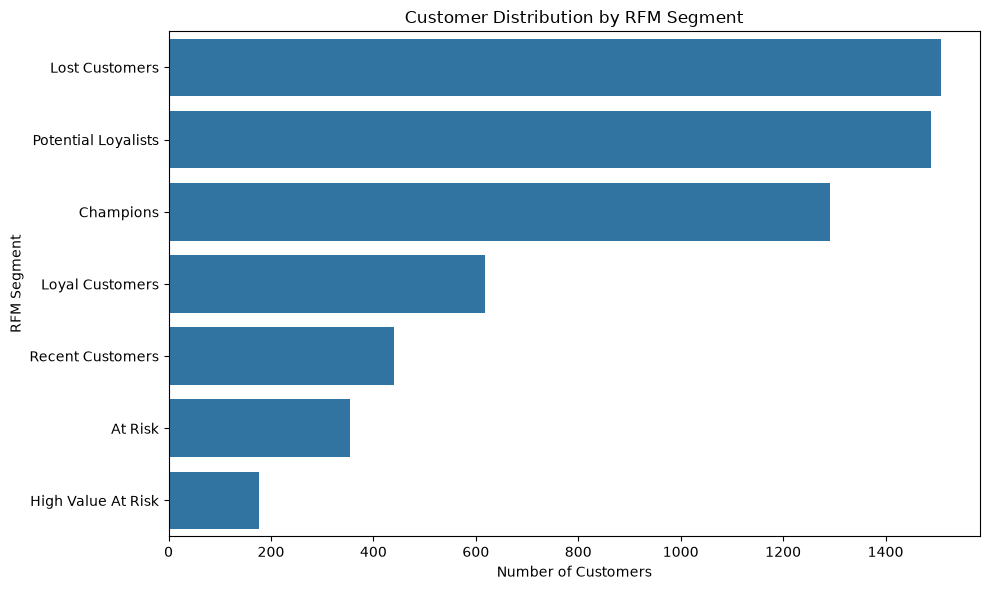

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x="customers",
    y="customer_segment"
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("RFM Segment")
plt.tight_layout()
plt.show()

### RFM Score Distribution

The combined RFM score summarizes customer engagement across
recency, frequency, and monetary value.

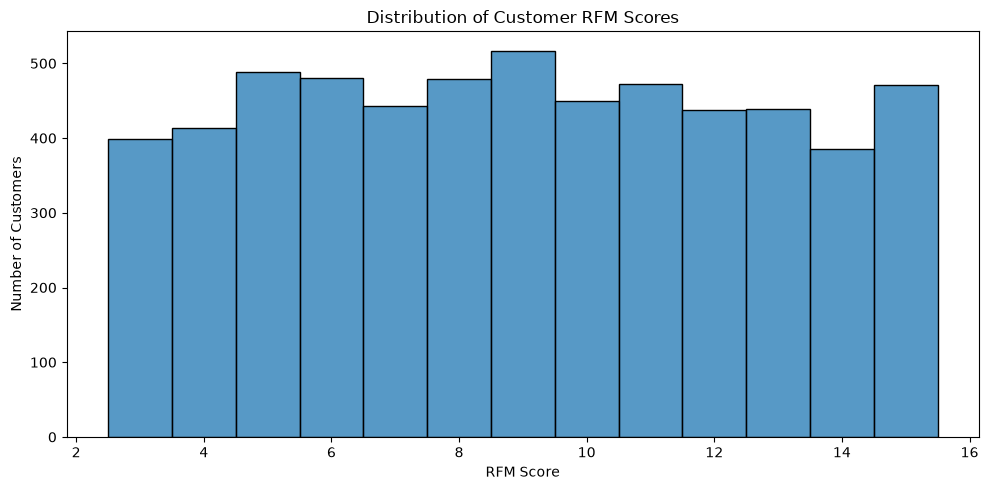

In [8]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=rfm,
    x="rfm_score",
    bins=15,
    discrete=True
)

plt.title("Distribution of Customer RFM Scores")
plt.xlabel("RFM Score")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [9]:
segment_metrics = (
    rfm.groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        avg_recency=("recency", "mean"),
        avg_frequency=("frequency", "mean"),
        avg_monetary=("monetary", "mean"),
        avg_rfm_score=("rfm_score", "mean"),
    )
    .sort_values("avg_rfm_score", ascending=False)
)

display(segment_metrics.round(2))

,customers,avg_recency,avg_frequency,avg_monetary,avg_rfm_score
customer_segment,,,,,
Champions,1292,19.1200,17.1200,"9,373.9000",13.9200
Loyal Customers,617,24.0600,3.8000,"1,381.3200",10.7800
At Risk,354,342.2700,7.5700,"3,168.7200",9.6900
Potential Loyalists,1489,165.7300,4.5700,"1,707.5000",8.8700
High Value At Risk,176,391.0200,2.7000,"2,622.4800",8.4500
Recent Customers,441,27.3200,1.4600,400.9000,7.7600
Lost Customers,1509,458.8000,1.2600,316.4500,4.4500


## 4. Cohort Retention Analysis

Cohort analysis tracks customers based on the month of their first
purchase and measures how many remain active in subsequent months.

This helps distinguish overall customer growth from actual customer
retention behavior.

In [10]:
cohort_query = """
    SELECT
        cohort_month,
        months_since_cohort,
        cohort_size,
        active_customers,
        retention_rate
    FROM cohort_retention
    ORDER BY cohort_month, months_since_cohort
"""

cohort = pd.read_sql(cohort_query, engine)

cohort["cohort_month"] = pd.to_datetime(cohort["cohort_month"])

print(f"Cohort records: {len(cohort):,}")
print(f"Total cohorts: {cohort['cohort_month'].nunique()}")
print(f"Maximum cohort age: {cohort['months_since_cohort'].max()} months")

display(cohort.head(10))

Cohort records: 325
Total cohorts: 25
Maximum cohort age: 24 months


,cohort_month,months_since_cohort,cohort_size,active_customers,retention_rate
0,2009-12-01,0,955,955,100.0000
1,2009-12-01,1,955,337,35.2900
2,2009-12-01,2,955,319,33.4000
3,2009-12-01,3,955,406,42.5100
4,2009-12-01,4,955,363,38.0100
5,2009-12-01,5,955,343,35.9200
6,2009-12-01,6,955,360,37.7000
7,2009-12-01,7,955,327,34.2400
8,2009-12-01,8,955,321,33.6100
9,2009-12-01,9,955,346,36.2300


### Retention Summary

The first month of each cohort represents the cohort's initial customer
base, so month-0 retention is expected to be 100%.

In [11]:
retention_summary = {
    "Total Cohorts": cohort["cohort_month"].nunique(),
    "Month 1 Retention": cohort.loc[
        cohort["months_since_cohort"] == 1,
        "retention_rate"
    ].mean(),
    "Average Retention": cohort["retention_rate"].mean(),
    "Maximum Cohort Age": cohort["months_since_cohort"].max(),
}

print(f"Total Cohorts: {retention_summary['Total Cohorts']}")
print(f"Month 1 Retention: {retention_summary['Month 1 Retention']:.2f}%")
print(f"Average Retention: {retention_summary['Average Retention']:.2f}%")
print(f"Maximum Cohort Age: {retention_summary['Maximum Cohort Age']} months")

Total Cohorts: 25
Month 1 Retention: 21.17%
Average Retention: 24.69%
Maximum Cohort Age: 24 months


In [12]:
print(f"Total Cohorts: {retention_summary['Total Cohorts']}")
print(f"Month 1 Retention: {retention_summary['Month 1 Retention']:.2%}")
print(f"Average Retention: {retention_summary['Average Retention']:.2%}")
print(f"Maximum Cohort Age: {retention_summary['Maximum Cohort Age']}")

Total Cohorts: 25
Month 1 Retention: 2116.62%
Average Retention: 2468.89%
Maximum Cohort Age: 24


### Average Retention Curve

The retention curve shows how the average percentage of customers
remaining active changes as the cohort ages.

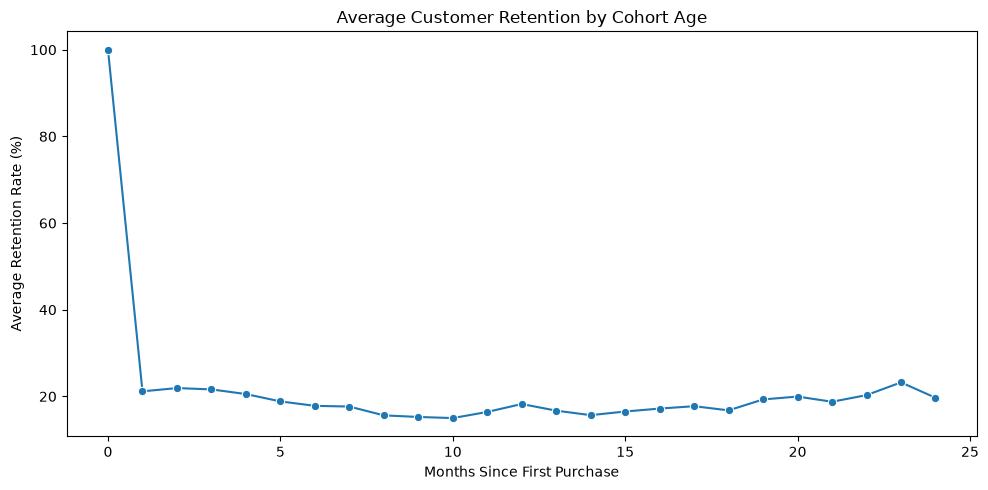

In [13]:
retention_curve = (
    cohort.groupby("months_since_cohort")["retention_rate"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=retention_curve,
    x="months_since_cohort",
    y="retention_rate",
    marker="o"
)

plt.title("Average Customer Retention by Cohort Age")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Average Retention Rate (%)")
plt.tight_layout()
plt.show()

### Cohort Retention Heatmap

The heatmap shows retention for each acquisition cohort across its
lifetime.

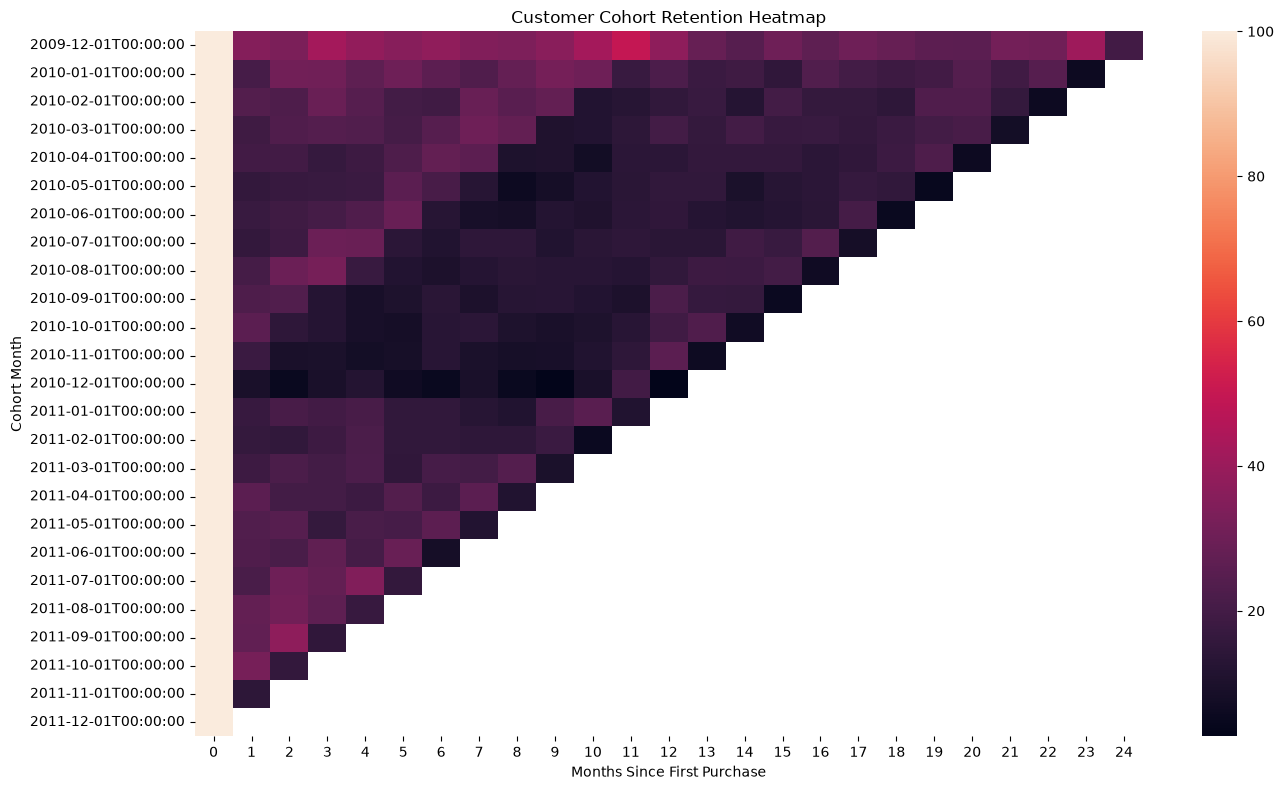

In [14]:
cohort_pivot = cohort.pivot(
    index="cohort_month",
    columns="months_since_cohort",
    values="retention_rate"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    cohort_pivot,
    annot=False,
    fmt=".1f"
)

plt.title("Customer Cohort Retention Heatmap")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.tight_layout()
plt.show()

### Cohort Size

Cohort size shows how many customers made their first purchase in each
acquisition month.

In [15]:
cohort_sizes = (
    cohort[cohort["months_since_cohort"] == 0]
    [["cohort_month", "cohort_size"]]
    .drop_duplicates()
    .sort_values("cohort_month")
)

display(cohort_sizes)

,cohort_month,cohort_size
0,2009-12-01,955
25,2010-01-01,383
49,2010-02-01,374
72,2010-03-01,443
94,2010-04-01,294
115,2010-05-01,254
135,2010-06-01,270
154,2010-07-01,186
172,2010-08-01,162
189,2010-09-01,243


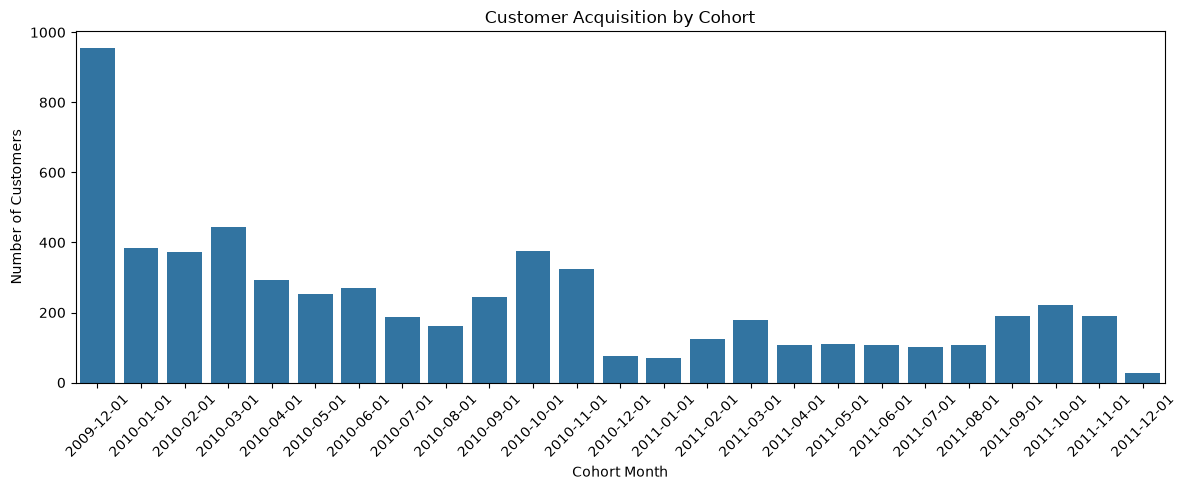

In [16]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=cohort_sizes,
    x="cohort_month",
    y="cohort_size"
)

plt.title("Customer Acquisition by Cohort")
plt.xlabel("Cohort Month")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Churn Analysis

For the Online Retail II dataset, there is no explicit churn label.
Therefore, churn is defined using an inactivity-based business rule.

A customer is classified as **churned** if their period of inactivity
from their last valid purchase reaches at least 90 days relative to the
analysis date.

This provides a reproducible behavioral definition of churn for
customer-retention analysis.

In [17]:
churn_query = """
    SELECT
        customer_id,
        first_purchase_date,
        last_purchase_date,
        observation_end_date,
        days_since_last_purchase,
        purchase_frequency,
        total_monetary_value,
        churn
    FROM customer_churn
"""

churn = pd.read_sql(churn_query, engine)

for column in [
    "first_purchase_date",
    "last_purchase_date",
    "observation_end_date"
]:
    churn[column] = pd.to_datetime(churn[column])

print(f"Customers in churn dataset: {len(churn):,}")
print(f"Churned customers: {churn['churn'].sum():,}")
print(f"Active customers: {(churn['churn'] == 0).sum():,}")

display(churn.head())

Customers in churn dataset: 5,878
Churned customers: 2,989
Active customers: 2,889


,customer_id,first_purchase_date,last_purchase_date,observation_end_date,days_since_last_purchase,purchase_frequency,total_monetary_value,churn
0,12346,2009-12-14,2011-01-18,2011-12-09,325,12,"77,556.4600",1
1,12347,2010-10-31,2011-12-07,2011-12-09,2,8,"5,633.3200",0
2,12348,2010-09-27,2011-09-25,2011-12-09,75,5,"2,019.4000",0
3,12349,2010-04-29,2011-11-21,2011-12-09,18,4,"4,428.6900",0
4,12350,2011-02-02,2011-02-02,2011-12-09,310,1,334.4000,1


### Churn Distribution

The churn label separates customers into active and inactive groups
according to the 90-day inactivity rule.

In [18]:
churn_summary = (
    churn["churn"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Active", 1: "Churned"})
    .rename_axis("status")
    .reset_index(name="customers")
)

churn_summary["percentage"] = (
    churn_summary["customers"] / len(churn) * 100
)

display(churn_summary)

,status,customers,percentage
0,Active,2889,49.1494
1,Churned,2989,50.8506


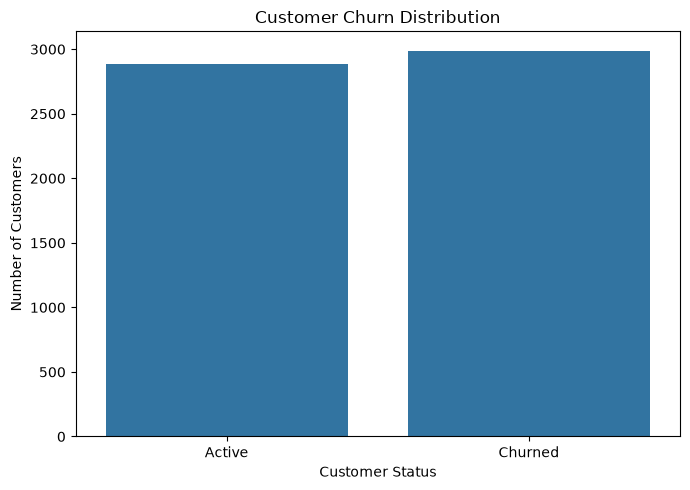

In [19]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=churn_summary,
    x="status",
    y="customers"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [20]:
total_customers = len(churn)
churned_customers = churn["churn"].sum()
active_customers = total_customers - churned_customers
churn_rate = churned_customers / total_customers * 100

print(f"Total customers : {total_customers:,}")
print(f"Churned         : {churned_customers:,}")
print(f"Active          : {active_customers:,}")
print(f"Churn rate      : {churn_rate:.2f}%")

Total customers : 5,878
Churned         : 2,989
Active          : 2,889
Churn rate      : 50.85%


### Customer Behavioral Features

Behavioral features such as purchase frequency, total spend,
active purchase months, product diversity, and return activity are
used to compare churned and active customers.

In [21]:
behavior_query = """
    SELECT *
    FROM customer_behavior_features
"""

behavior = pd.read_sql(behavior_query, engine)

print(f"Behavior rows: {len(behavior):,}")
print("Behavior columns:")
print(behavior.columns.tolist())

display(behavior.head())

Behavior rows: 5,878
Behavior columns:
['customer_id', 'purchase_frequency', 'total_spend', 'average_line_value', 'active_purchase_months', 'unique_products_purchased', 'total_units_purchased', 'total_purchase_lines', 'first_purchase_date', 'last_purchase_date', 'return_lines', 'returned_units', 'average_order_value', 'return_line_rate']


,customer_id,purchase_frequency,total_spend,average_line_value,active_purchase_months,unique_products_purchased,total_units_purchased,total_purchase_lines,first_purchase_date,last_purchase_date,return_lines,returned_units,average_order_value,return_line_rate
0,12346,12,"77,556.4600","2,281.0700",5,27,74285,34,2009-12-14,2011-01-18,14,74233,"6,463.0400",0.4118
1,12347,8,"5,633.3200",22.2700,8,126,3286,253,2010-10-31,2011-12-07,0,0,704.1700,0.0000
2,12348,5,"2,019.4000",39.6000,5,25,2714,51,2010-09-27,2011-09-25,0,0,403.8800,0.0000
3,12349,4,"4,428.6900",25.3100,4,138,1624,175,2010-04-29,2011-11-21,5,5,"1,107.1700",0.0286
4,12350,1,334.4000,19.6700,1,17,197,17,2011-02-02,2011-02-02,0,0,334.4000,0.0000


In [22]:
churn_behavior = (
    churn[
        [
            "customer_id",
            "churn",
            "days_since_last_purchase",
            "total_monetary_value",
        ]
    ]
    .merge(
        behavior,
        on="customer_id",
        how="left"
    )
)

print(f"Combined rows: {len(churn_behavior):,}")

display(
    churn_behavior[
        [
            "customer_id",
            "churn",
            "days_since_last_purchase",
            "purchase_frequency",
            "total_monetary_value",
            "total_spend",
            "active_purchase_months",
            "unique_products_purchased",
        ]
    ].head()
)

Combined rows: 5,878


,customer_id,churn,days_since_last_purchase,purchase_frequency,total_monetary_value,total_spend,active_purchase_months,unique_products_purchased
0,12346,1,325,12,"77,556.4600","77,556.4600",5,27
1,12347,0,2,8,"5,633.3200","5,633.3200",8,126
2,12348,0,75,5,"2,019.4000","2,019.4000",5,25
3,12349,0,18,4,"4,428.6900","4,428.6900",4,138
4,12350,1,310,1,334.4000,334.4000,1,17


In [23]:
behavior_comparison = (
    churn_behavior
    .groupby("churn")[
        [
            "days_since_last_purchase",
            "purchase_frequency",
            "total_spend",
            "active_purchase_months",
            "unique_products_purchased",
            "total_units_purchased",
            "average_order_value",
            "return_line_rate",
        ]
    ]
    .median()
    .rename(index={0: "Active", 1: "Churned"})
)

display(behavior_comparison.round(2))

,days_since_last_purchase,purchase_frequency,total_spend,active_purchase_months,unique_products_purchased,total_units_purchased,average_order_value,return_line_rate
churn,,,,,,,,
Active,25.0000,5.0000,"1,686.2800",5.0000,77.0000,982.0000,313.6000,0.0000
Churned,378.0000,2.0000,496.0000,2.0000,28.0000,270.0000,253.8900,0.0000


### Statistical Testing

Mann–Whitney U tests are used to compare behavioral features between
active and churned customers.

Because multiple features are tested simultaneously, p-values are
adjusted using the Benjamini–Hochberg false discovery rate procedure.

Effect size is reported alongside statistical significance to provide
an indication of the practical strength of the association.

In [24]:
churn_stats = pd.read_csv(
    RESULTS_DIR / "churn_statistical_tests.csv"
)

display(churn_stats)

,feature,non_churned_median,churned_median,u_statistic,p_value,effect_size,adjusted_p_value,significant
0,active_purchase_months,5.0000,2.0000,"6,559,089.5000",0.0000,0.4495,0.0000,True
1,purchase_frequency,5.0000,2.0000,"6,557,856.5000",0.0000,0.4492,0.0000,True
2,total_units_purchased,982.0000,270.0000,"6,497,269.0000",0.0000,0.4371,0.0000,True
3,total_spend,"1,686.2800",496.0000,"6,452,791.0000",0.0000,0.4282,0.0000,True
4,total_purchase_lines,105.0000,31.0000,"6,445,425.0000",0.0000,0.4267,0.0000,True
5,unique_products_purchased,77.0000,28.0000,"6,326,800.5000",0.0000,0.4029,0.0000,True
6,return_lines,1.0000,0.0000,"5,436,128.0000",0.0000,0.2243,0.0000,True
7,returned_units,1.0000,0.0000,"5,401,381.5000",0.0000,0.2173,0.0000,True
8,average_order_value,313.6000,253.8900,"5,147,376.5000",0.0000,0.1664,0.0000,True
9,return_line_rate,0.0050,0.0000,"5,006,317.5000",0.0000,0.1381,0.0000,True


In [25]:
significant_churn = (
    churn_stats[
        churn_stats["significant"] == True
    ]
    .sort_values("effect_size", ascending=False)
)

display(
    significant_churn[
        [
            "feature",
            "adjusted_p_value",
            "effect_size"
        ]
    ].round(6)
)

,feature,adjusted_p_value,effect_size
0,active_purchase_months,0.0000,0.4495
1,purchase_frequency,0.0000,0.4492
2,total_units_purchased,0.0000,0.4371
3,total_spend,0.0000,0.4282
4,total_purchase_lines,0.0000,0.4267
5,unique_products_purchased,0.0000,0.4029
6,return_lines,0.0000,0.2243
7,returned_units,0.0000,0.2173
8,average_order_value,0.0000,0.1664
9,return_line_rate,0.0000,0.1381


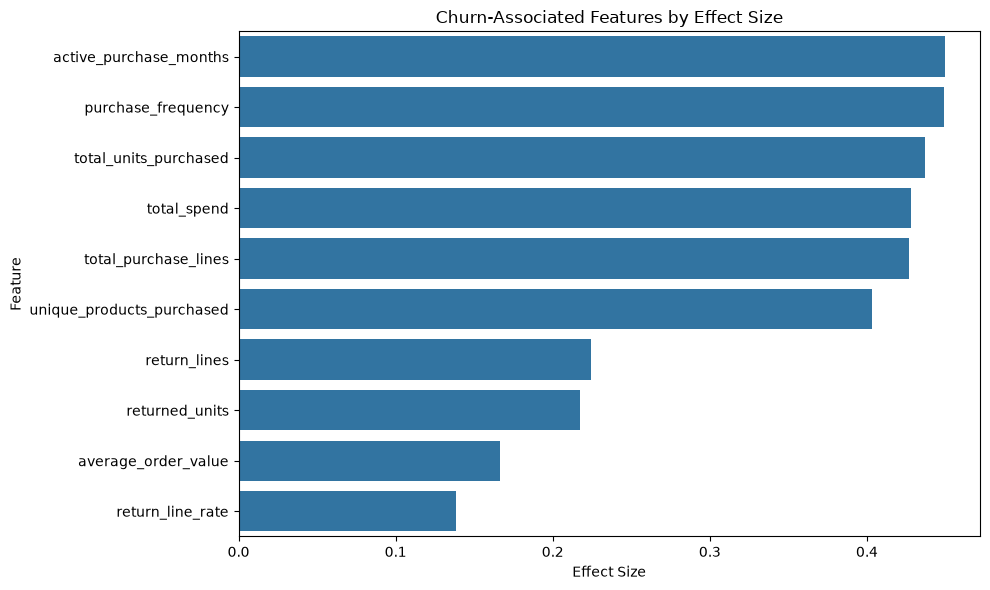

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=significant_churn,
    x="effect_size",
    y="feature"
)

plt.title("Churn-Associated Features by Effect Size")
plt.xlabel("Effect Size")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Interpretation

The statistical analysis indicates that customer engagement and
purchase intensity are strongly associated with churn status.

Customers with differences in active purchase months, purchase
frequency, total units purchased, total spend, and product diversity
show statistically significant differences between churned and active
groups.

These results indicate **association rather than causation**. The
analysis identifies behavioral characteristics associated with churn;
it does not establish that changing any individual feature will
directly prevent churn.

## 6. Churn Prediction

A time-based modeling approach is used to predict future customer
inactivity.

Instead of randomly splitting historical observations, customer
snapshots from earlier dates are used for training and a later
snapshot is held out for testing.

This better reflects the real-world use case of predicting which
currently active customers may become inactive in the future.

In [27]:
chronological_metrics = pd.read_csv(
    RESULTS_DIR / "chronological_churn_model_metrics.csv"
)

display(chronological_metrics)

,model,roc_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.7595,0.7813,0.7218,0.7822,0.7508
1,Random Forest,0.8163,0.8231,0.7335,0.9086,0.8117


In [28]:
model_comparison = chronological_metrics[
    [
        "model",
        "roc_auc",
        "pr_auc",
        "precision",
        "recall",
        "f1",
    ]
].copy()

display(
    model_comparison.style.format({
        "roc_auc": "{:.4f}",
        "pr_auc": "{:.4f}",
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
    })
)

,model,roc_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.7595,0.7813,0.7218,0.7822,0.7508
1,Random Forest,0.8163,0.8231,0.7335,0.9086,0.8117


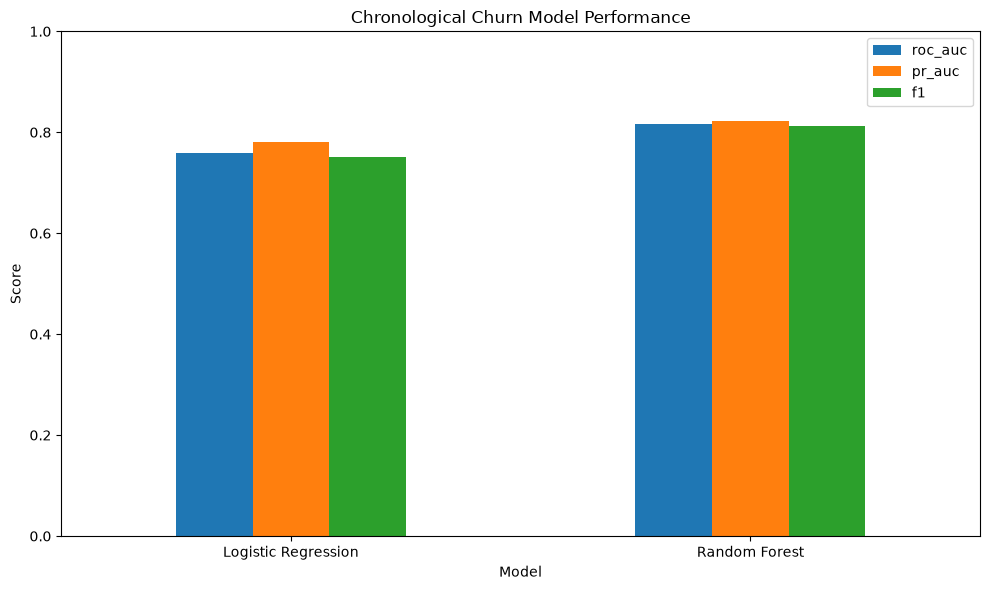

In [29]:
model_plot = model_comparison.set_index("model")[
    ["roc_auc", "pr_auc", "f1"]
]

ax = model_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

ax.set_title("Chronological Churn Model Performance")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [30]:
best_model = chronological_metrics.loc[
    chronological_metrics["roc_auc"].idxmax()
]

print("Best model by ROC-AUC:")
print(best_model)

Best model by ROC-AUC:
model        Random Forest
roc_auc             0.8163
pr_auc              0.8231
precision           0.7335
recall              0.9086
f1                  0.8117
Name: 1, dtype: object


In [31]:
churn_rf_importance = pd.read_csv(
    RESULTS_DIR / "random_forest_chronological_feature_importance.csv"
)

display(churn_rf_importance.head(10))

,feature,importance,model
0,total_units_purchased,0.1608,Random Forest
1,total_spend,0.1583,Random Forest
2,average_order_value,0.1095,Random Forest
3,average_line_value,0.1049,Random Forest
4,total_purchase_lines,0.0994,Random Forest
5,purchase_frequency,0.0950,Random Forest
6,active_purchase_months,0.0911,Random Forest
7,unique_products_purchased,0.0843,Random Forest
8,return_line_rate,0.0392,Random Forest
9,returned_units,0.0350,Random Forest


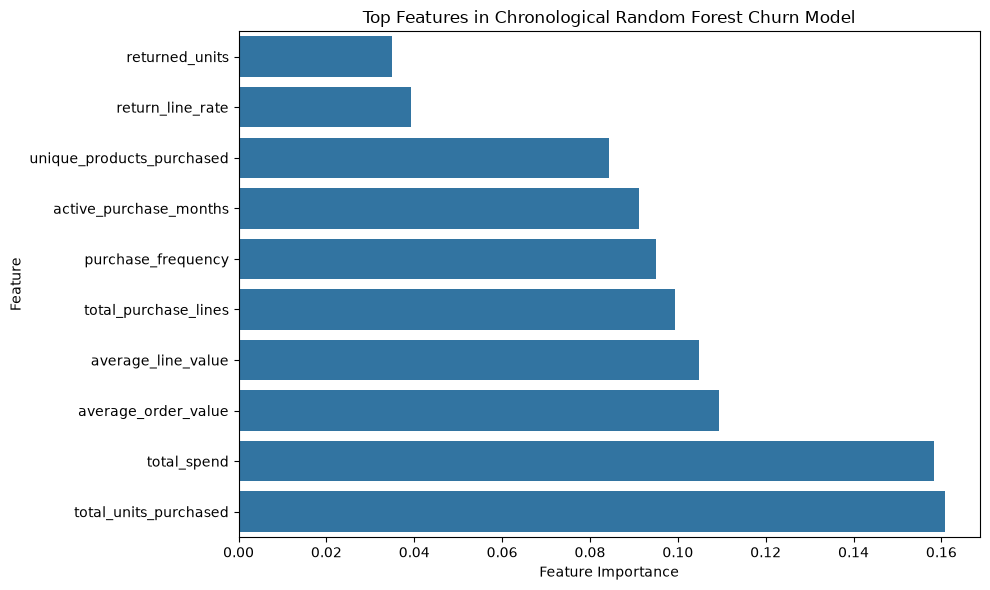

In [32]:
top_churn_features = (
    churn_rf_importance
    .sort_values("importance", ascending=False)
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_churn_features,
    x="importance",
    y="feature"
)

plt.title("Top Features in Chronological Random Forest Churn Model")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [33]:
rf_confusion = pd.read_csv(
    RESULTS_DIR / "random_forest_chronological_confusion_matrix.csv",
    index_col=0
)

display(rf_confusion)

,predicted_0,predicted_1
actual_0,1248,993
actual_1,275,2733


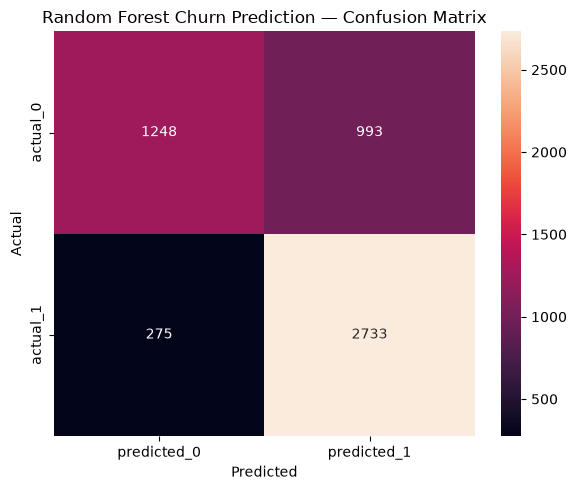

In [34]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    rf_confusion,
    annot=True,
    fmt="g"
)

plt.title("Random Forest Churn Prediction — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Interpretation

The Random Forest model performs better than Logistic Regression on
the chronological holdout, achieving the highest ROC-AUC, PR-AUC, and
F1 score.

The model also achieves high recall, meaning it identifies a large
proportion of customers who subsequently become inactive.

The most important predictive features are primarily related to
purchase volume, customer spending, order value, purchase frequency,
and the number of active purchasing months.

Feature importance indicates predictive usefulness within the model;
it should not be interpreted as causal influence.

## 7. Marketing Campaign Analysis

The Customer Personality Analysis dataset contains customer-level
demographic, purchasing, channel, and campaign-response information.

The analysis focuses on understanding which customer characteristics
and behaviors are associated with response to the latest marketing
campaign.

In [35]:
marketing_query = """
    SELECT *
    FROM marketing_customer_features
"""

marketing = pd.read_sql(marketing_query, engine)

print(f"Marketing customers: {len(marketing):,}")
print(f"Features available: {marketing.shape[1]}")

display(marketing.head())

Marketing customers: 2,240
Features available: 41


,customer_id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,mnt_fruits,mnt_meat_products,mnt_fish_products,mnt_sweet_products,mnt_gold_prods,num_deals_purchases,num_web_purchases,num_catalog_purchases,num_store_purchases,num_web_visits_month,accepted_cmp1,accepted_cmp2,accepted_cmp3,accepted_cmp4,accepted_cmp5,complain,response,total_spend,total_purchases,total_campaign_acceptances,total_children,household_size,total_channel_purchases,web_purchase_share,catalog_purchase_share,store_purchase_share,accepted_any_campaign,approximate_age_2014,wine_spend_share,meat_spend_share,gold_spend_share
0,5524,1957,Graduation,Single,"58,138.0000",0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,1617,22,0,0,1,22,0.3636,0.4545,0.1818,0,57,0.3927,0.3377,0.0544
1,2174,1954,Graduation,Single,"46,344.0000",1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,27,4,0,2,3,4,0.2500,0.2500,0.5000,0,60,0.4074,0.2222,0.2222
2,4141,1965,Graduation,Together,"71,613.0000",0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,776,20,0,0,1,20,0.4000,0.1000,0.5000,0,49,0.5490,0.1637,0.0541
3,6182,1984,Graduation,Together,"26,646.0000",1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,53,6,0,1,2,6,0.3333,0.0000,0.6667,0,30,0.2075,0.3774,0.0943
4,5324,1981,PhD,Married,"58,293.0000",1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,422,14,0,1,2,14,0.3571,0.2143,0.4286,0,33,0.4100,0.2796,0.0355


In [36]:
response_summary = (
    marketing["response"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No Response", 1: "Responded"})
    .rename_axis("response_status")
    .reset_index(name="customers")
)

response_summary["percentage"] = (
    response_summary["customers"] / len(marketing) * 100
)

display(response_summary)

,response_status,customers,percentage
0,No Response,1906,85.0893
1,Responded,334,14.9107


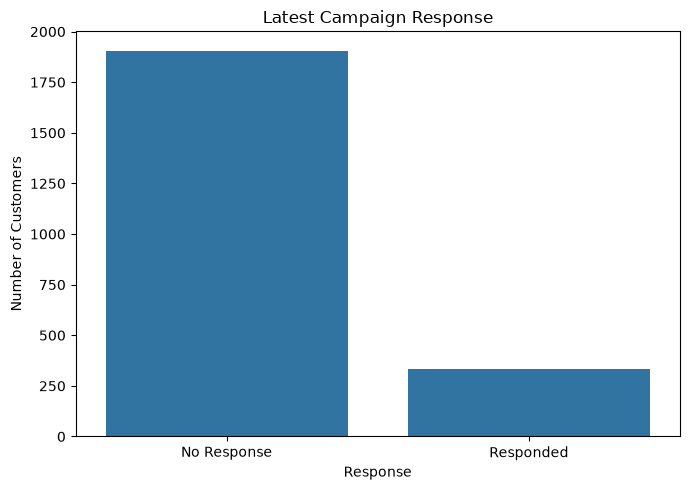

In [37]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=response_summary,
    x="response_status",
    y="customers"
)

plt.title("Latest Campaign Response")
plt.xlabel("Response")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [38]:
campaign_education = pd.read_csv(
    RESULTS_DIR / "campaign_response_by_education.csv"
)

display(campaign_education)

,education,customers,responders,response_rate,average_spend
0,2n Cycle,203,22,10.8374,496.5271
1,Basic,54,2,3.7037,81.7963
2,Graduation,1127,152,13.4871,619.8988
3,Master,370,57,15.4054,611.7811
4,PhD,486,101,20.7819,672.4095


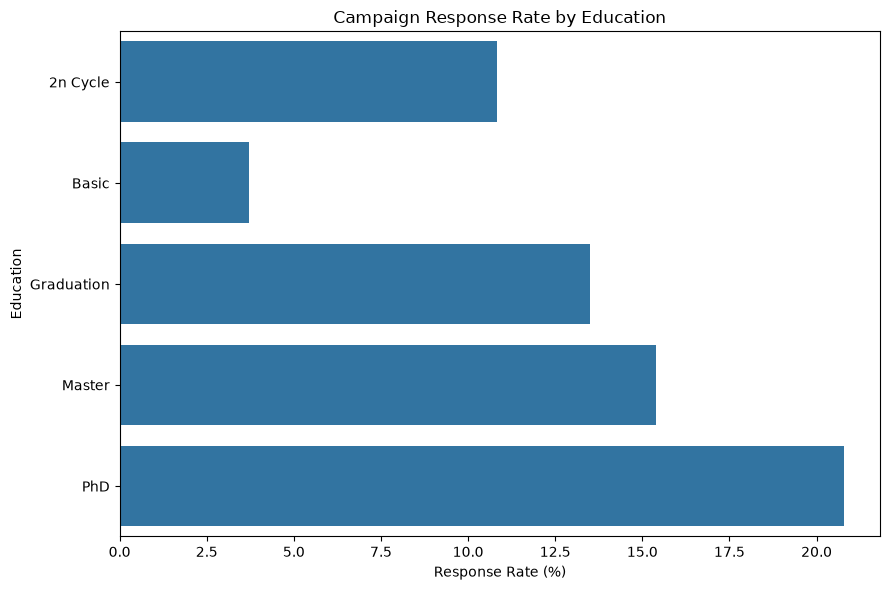

In [39]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=campaign_education,
    x="response_rate",
    y="education"
)

plt.title("Campaign Response Rate by Education")
plt.xlabel("Response Rate (%)")
plt.ylabel("Education")
plt.tight_layout()
plt.show()

### Campaign Response by Customer Value

Customers are divided into four value groups based on total customer
spend. This helps examine whether higher-value customers are more likely
to respond to the latest campaign.

In [40]:
campaign_value = pd.read_csv(
    RESULTS_DIR / "campaign_response_by_value.csv"
)

display(campaign_value)

,spend_quartile,customers,responders,response_rate,average_spend,average_purchases
0,1,560,31,5.5357,39.2625,4.3125
1,2,561,69,12.2995,184.5740,8.2692
2,3,559,66,11.8068,709.8193,17.5903
3,4,560,168,30.0000,"1,490.4750",19.9929


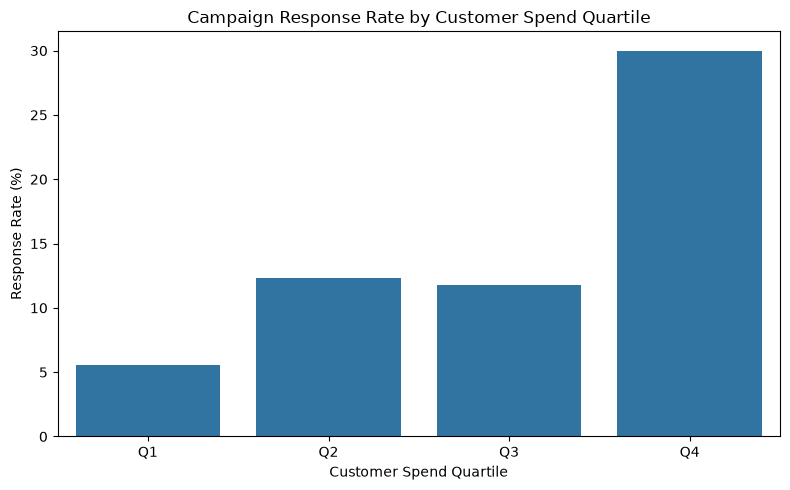

In [41]:
campaign_value_plot = campaign_value.copy()

campaign_value_plot["spend_group"] = (
    "Q" + campaign_value_plot["spend_quartile"].astype(str)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=campaign_value_plot,
    x="spend_group",
    y="response_rate",
    order=["Q1", "Q2", "Q3", "Q4"]
)

plt.title("Campaign Response Rate by Customer Spend Quartile")
plt.xlabel("Customer Spend Quartile")
plt.ylabel("Response Rate (%)")
plt.tight_layout()
plt.show()

In [42]:
campaign_engagement = (
    marketing["total_campaign_acceptances"]
    .value_counts()
    .sort_index()
    .rename_axis("historical_acceptances")
    .reset_index(name="customers")
)

display(campaign_engagement)

,historical_acceptances,customers
0,0,1777
1,1,325
2,2,83
3,3,44
4,4,11


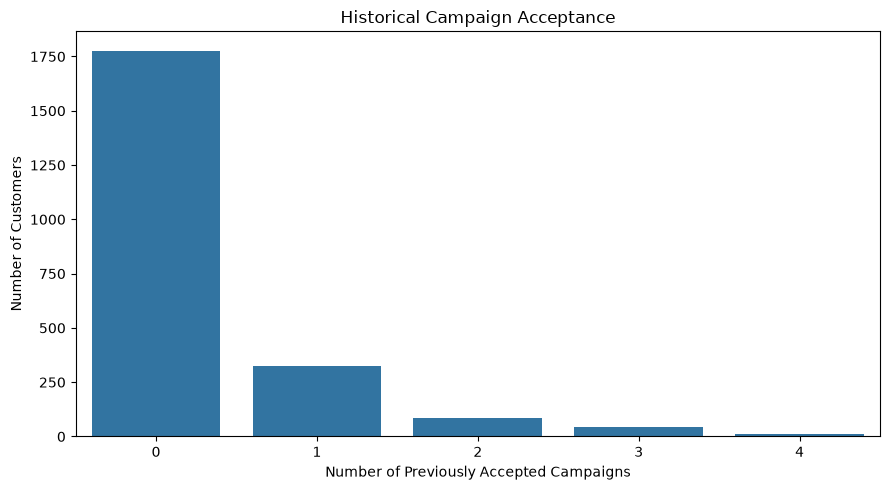

In [43]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=campaign_engagement,
    x="historical_acceptances",
    y="customers"
)

plt.title("Historical Campaign Acceptance")
plt.xlabel("Number of Previously Accepted Campaigns")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Statistical Analysis

Statistical tests are used to identify customer characteristics that
are significantly associated with response to the latest campaign.

- Chi-square tests are used for categorical variables.
- Mann–Whitney U tests are used for numeric variables.
- Benjamini–Hochberg FDR correction is applied to control for multiple comparisons.
- Effect size is used alongside statistical significance to identify stronger associations.

These results indicate associations rather than causal relationships.

In [44]:
campaign_numeric_stats = pd.read_csv(
    RESULTS_DIR / "campaign_numeric_tests.csv"
)

campaign_categorical_stats = pd.read_csv(
    RESULTS_DIR / "campaign_categorical_tests.csv"
)

print("Numeric tests:")
display(campaign_numeric_stats)

print("Categorical tests:")
display(campaign_categorical_stats)

Numeric tests:


,feature,responder_median,non_responder_median,u_statistic,p_value,effect_size,adjusted_p_value,significant
0,income,"64,090.0000","50,150.0000","395,125.5000",0.0000,0.1611,0.0000,True
1,recency,30.0000,52.0000,"216,066.0000",0.0000,0.1981,0.0000,True
2,total_spend,"1,057.5000",314.0000,"441,421.5000",0.0000,0.2386,0.0000,True
3,total_purchases,16.0000,11.0000,"403,790.5000",0.0000,0.1659,0.0000,True
4,total_children,0.0000,1.0000,"234,887.5000",0.0000,0.1761,0.0000,True
5,household_size,1.0000,2.0000,"234,887.5000",0.0000,0.1761,0.0000,True
6,num_deals_purchases,1.0000,2.0000,"300,673.0000",0.0892,0.0359,0.0956,False
7,num_web_purchases,5.0000,3.0000,"406,722.0000",0.0000,0.1727,0.0000,True
8,num_catalog_purchases,4.0000,1.0000,"436,666.5000",0.0000,0.2332,0.0000,True
9,num_store_purchases,6.0000,5.0000,"345,600.0000",0.0116,0.0533,0.0145,True


Categorical tests:


,feature,chi2,p_value,degrees_of_freedom
0,education,23.0761,0.0001,4
1,marital_status,54.2416,0.0000,7


In [45]:
significant_campaign = (
    campaign_numeric_stats[
        campaign_numeric_stats["significant"] == True
    ]
    .sort_values("effect_size", ascending=False)
)

display(
    significant_campaign[
        [
            "feature",
            "adjusted_p_value",
            "effect_size"
        ]
    ].round(6)
)

,feature,adjusted_p_value,effect_size
11,total_campaign_acceptances,0.0000,0.3877
14,store_purchase_share,0.0000,0.2796
13,catalog_purchase_share,0.0000,0.2531
2,total_spend,0.0000,0.2386
8,num_catalog_purchases,0.0000,0.2332
1,recency,0.0000,0.1981
5,household_size,0.0000,0.1761
4,total_children,0.0000,0.1761
7,num_web_purchases,0.0000,0.1727
3,total_purchases,0.0000,0.1659


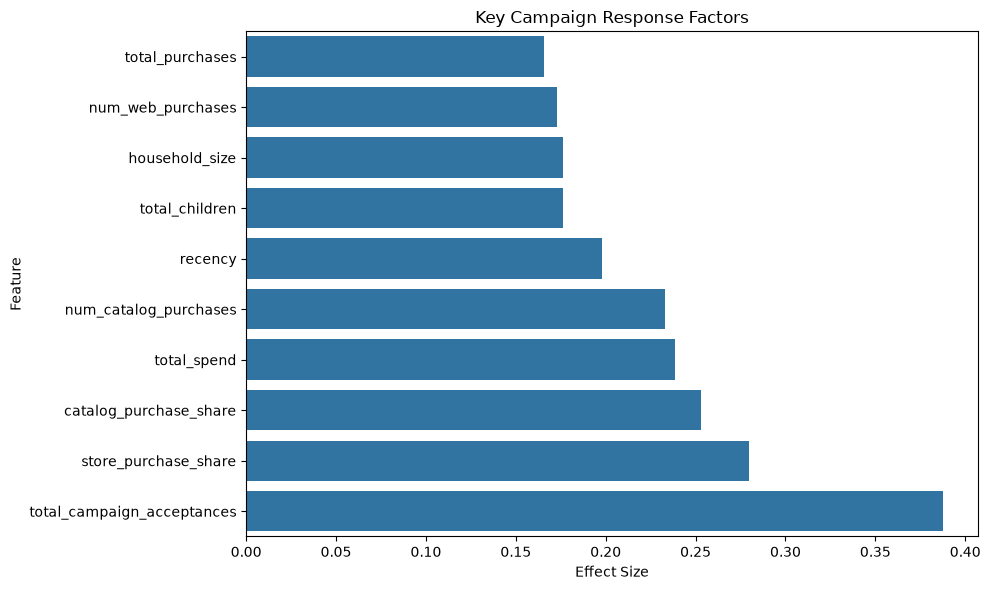

In [46]:
top_campaign_features = (
    significant_campaign
    .head(10)
    .sort_values("effect_size")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_campaign_features,
    x="effect_size",
    y="feature"
)

plt.title("Key Campaign Response Factors")
plt.xlabel("Effect Size")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Interpretation

The campaign analysis shows that response to the latest campaign is
strongly associated with previous campaign engagement, customer value,
recency, income, and purchasing behavior.

Customers with previous campaign acceptances are substantially more
likely to respond to the latest campaign. Customer spend also shows a
strong relationship with response, with higher-value customers having
considerably higher response rates.

These findings can support customer prioritization for future campaigns.
However, the statistical tests identify associations and should not be
interpreted as evidence that any individual factor directly causes
campaign response.

## 8. Campaign Response Prediction

This section uses machine learning to predict whether a customer will
respond to the latest marketing campaign.

Two classification models are evaluated:

- Logistic Regression
- Random Forest

The Customer Personality Analysis dataset is treated as a cross-sectional
dataset, so a stratified 80/20 train-test split is used.

Evaluation focuses on:

- ROC-AUC
- PR-AUC
- Precision
- Recall
- F1-score

Because campaign response is relatively uncommon, PR-AUC and F1-score
provide useful additional perspectives beyond ROC-AUC.

In [47]:
campaign_model_metrics = pd.read_csv(
    RESULTS_DIR / "campaign_model_metrics.csv"
)

display(campaign_model_metrics.round(4))

,model,roc_auc,pr_auc,precision,recall,f1
0,Logistic Regression,0.8723,0.5898,0.3968,0.7463,0.5181
1,Random Forest,0.8841,0.6232,0.5556,0.5970,0.5755


In [48]:
model_comparison = campaign_model_metrics.set_index("model")[
    ["roc_auc", "pr_auc", "precision", "recall", "f1"]
]

display(model_comparison.round(4))

,roc_auc,pr_auc,precision,recall,f1
model,,,,,
Logistic Regression,0.8723,0.5898,0.3968,0.7463,0.5181
Random Forest,0.8841,0.6232,0.5556,0.5970,0.5755


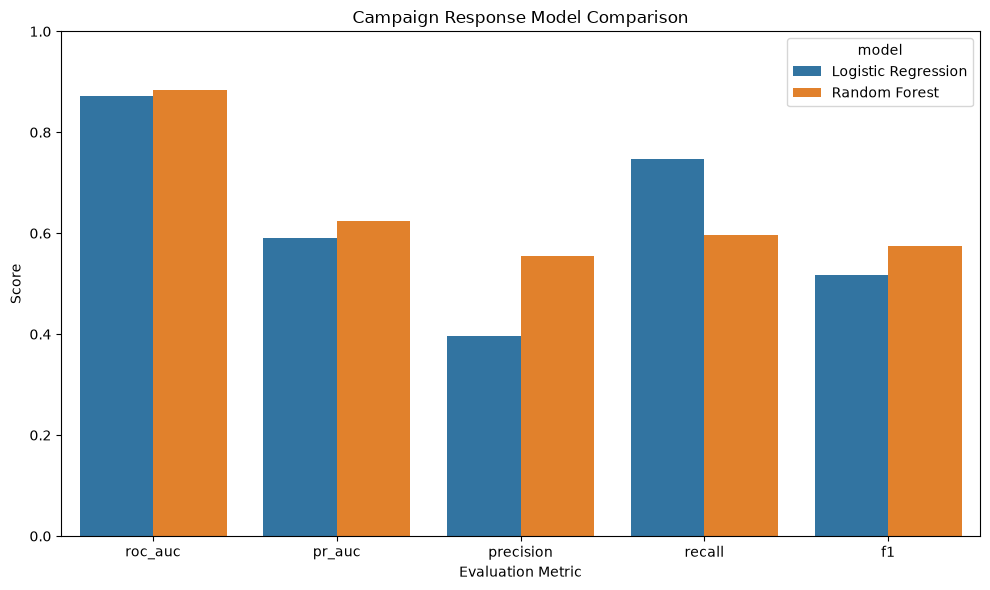

In [49]:
model_plot = campaign_model_metrics.melt(
    id_vars="model",
    value_vars=["roc_auc", "pr_auc", "precision", "recall", "f1"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_plot,
    x="metric",
    y="score",
    hue="model"
)

plt.title("Campaign Response Model Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [50]:
best_campaign_model = campaign_model_metrics.loc[
    campaign_model_metrics["roc_auc"].idxmax()
]

print("Best model based on ROC-AUC:")
display(best_campaign_model.to_frame().T)

Best model based on ROC-AUC:


,model,roc_auc,pr_auc,precision,recall,f1
1,Random Forest,0.8841,0.6232,0.5556,0.5970,0.5755


### Model Comparison

Random Forest performs better than Logistic Regression across the main
ranking metrics, achieving a ROC-AUC of approximately 0.884 and a PR-AUC
of approximately 0.623.

Random Forest also achieves higher precision and F1-score, while Logistic
Regression achieves higher recall.

Therefore, Random Forest provides the stronger overall predictive model
for this dataset under the selected evaluation criteria.

In [51]:
campaign_rf_importance = pd.read_csv(
    RESULTS_DIR / "campaign_random_forest_feature_importance.csv"
)

campaign_rf_importance = campaign_rf_importance.sort_values(
    "importance",
    ascending=False
)

display(campaign_rf_importance.head(15))

,feature,importance
0,recency,0.1358
1,total_campaign_acceptances,0.1245
2,total_spend,0.1156
3,store_purchase_share,0.1065
4,income,0.0972
5,catalog_purchase_share,0.0738
6,num_web_visits_month,0.0636
7,web_purchase_share,0.0498
8,total_purchases,0.0426
9,num_catalog_purchases,0.0409


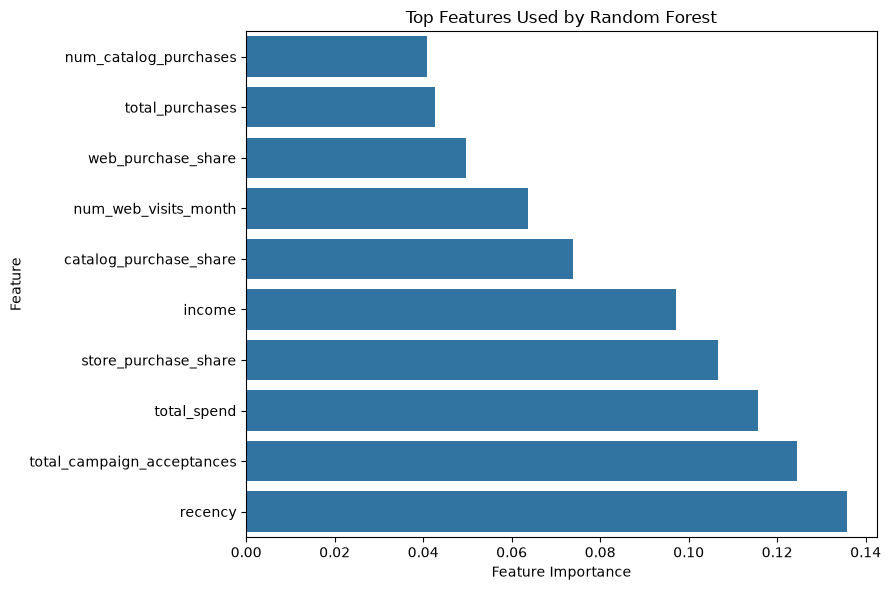

In [52]:
top_campaign_rf = (
    campaign_rf_importance
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=top_campaign_rf,
    x="importance",
    y="feature"
)

plt.title("Top Features Used by Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [53]:
campaign_rf_cm = pd.read_csv(
    RESULTS_DIR / "campaign_random_forest_confusion_matrix.csv",
    index_col=0
)

display(campaign_rf_cm)

,predicted_0,predicted_1
actual_0,349,32
actual_1,27,40


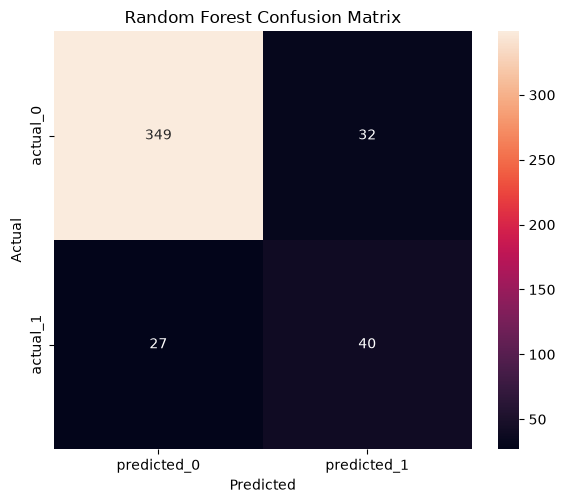

In [54]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    campaign_rf_cm,
    annot=True,
    fmt="d",
    square=True
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Interpretation

The Random Forest model provides the strongest overall predictive
performance, achieving a ROC-AUC of approximately 0.884 and a PR-AUC
of approximately 0.623.

The model identifies customer recency, previous campaign engagement,
customer spending, purchasing channels, income, and purchase behavior
as important predictive features.

Previous campaign acceptance is particularly informative, suggesting
that historical engagement can help prioritize customers for future
campaign outreach.

Feature importance should be interpreted as predictive importance rather
than causal influence. The model identifies patterns useful for
prediction but does not establish that changing any individual feature
would cause a customer to respond.

## 9. Business Insights & Conclusion

This section consolidates the key findings from customer segmentation,
retention analysis, churn analysis, and marketing campaign analysis.

The objective is to translate the analytical and predictive results into
practical business actions while clearly distinguishing association from
causation.

### 9.2 Customer Segmentation and Retention

RFM analysis provides a framework for differentiating customers according
to recency, purchase frequency, and monetary value.

The segmentation identifies groups such as Champions, Loyal Customers,
Recent Customers, At Risk, High Value At Risk, Lost Customers, and
Potential Loyalists.

This segmentation can support differentiated customer strategies rather
than treating the entire customer base uniformly.

Cohort analysis shows that customer retention declines as the time since
first purchase increases. The dataset contains 25 customer cohorts with
a maximum observable cohort age of 24 months.

The average Month 1 retention and overall retention metrics calculated
earlier in the notebook provide a baseline for evaluating future
retention initiatives.

### 9.3 Churn Insights

Using a 90-day inactivity rule, approximately half of the customers in
the Online Retail II customer population are classified as churned.

The strongest behavioral differences between active and churned customers
are associated with:

- Active purchase months
- Purchase frequency
- Total units purchased
- Total spend
- Total purchase lines
- Number of unique products purchased

These results suggest that sustained purchasing activity and customer
engagement are important indicators of future customer status.

The statistical analysis identifies associations rather than causal
relationships.

The full-history churn dataset contains 5,878 customers, of whom 2,989
are classified as churned, corresponding to a churn rate of approximately
50.9%.

### 9.4 Churn Prediction

The chronological churn prediction experiment evaluates whether earlier
customer behavior can predict churn at a later point in time.

Random Forest outperformed Logistic Regression on the main ranking
metrics:

- ROC-AUC: approximately 0.816
- PR-AUC: approximately 0.823
- Precision: approximately 0.734
- Recall: approximately 0.909
- F1-score: approximately 0.812

The most important predictive features include purchase volume, total
spend, average order value, purchase frequency, active purchase months,
and product breadth.

These features can potentially support early identification of customers
who may require retention attention.

Model feature importance represents predictive usefulness and should not
be interpreted as causal influence.

### 9.5 Marketing Campaign Insights

The latest campaign received responses from 334 out of 2,240 customers,
corresponding to an overall response rate of approximately 14.9%.

Customer value shows a substantial relationship with campaign response.

The highest-spending quartile had a response rate of approximately 30.0%,
while the lowest-spending quartile had a response rate of approximately
5.5%.

Campaign response also varies across education groups. For example,
customers in the PhD group had a response rate of approximately 20.8%,
while the Basic education group had a response rate of approximately
3.7%.

Historical campaign acceptance is also strongly associated with response
to the latest campaign, making previous engagement an important signal
for campaign targeting.

### 9.6 Campaign Response Prediction

The campaign response prediction models show that customer-level
behavior can provide useful signals for identifying likely campaign
responders.

Random Forest achieved the strongest overall performance:

- ROC-AUC: approximately 0.884
- PR-AUC: approximately 0.623
- Precision: approximately 0.556
- Recall: approximately 0.597
- F1-score: approximately 0.576

Important predictive features include:

- Recency
- Previous campaign acceptances
- Total spend
- Store purchase share
- Income
- Catalog purchase share
- Web visits and purchasing behavior

The model can therefore be viewed as a prioritization tool for campaign
outreach rather than as a guarantee that a customer will respond.

### 9.7 Business Recommendations

Based on the combined analysis, several practical strategies emerge.

**1. Prioritize high-value customers**

Customers with high monetary value and strong purchasing activity can be
prioritized for retention and targeted campaign initiatives.

**2. Identify customers showing early signs of disengagement**

Recency, purchase frequency, active purchase months, and purchasing volume
can be monitored to identify customers whose engagement is declining.

**3. Use RFM segments for differentiated retention strategies**

Champions and Loyal Customers can receive loyalty-oriented initiatives,
while At Risk and High Value At Risk customers can be targeted with
reactivation strategies.

**4. Use historical engagement for campaign prioritization**

Customers who have previously accepted campaigns are substantially more
likely to respond to the latest campaign. Historical engagement can
therefore be incorporated into campaign prioritization.

**5. Consider customer value when allocating campaign resources**

The large difference in response rates across spending quartiles suggests
that customer value can be considered when prioritizing campaign
outreach.

**6. Combine statistical analysis with predictive modeling**

Statistical tests help identify important associations, while predictive
models help rank customers according to their likelihood of belonging
to a target class. Using both approaches provides a more complete
analytical workflow.

### 9.8 Limitations

- The Online Retail II dataset does not contain an explicit churn label.
  Churn is therefore defined using a reproducible 90-day inactivity rule.
- The Customer Personality Analysis and Online Retail II datasets
  represent separate customer populations and are not joined together.
- Campaign response analysis is based on the available historical
  campaign data and does not establish causal effects.
- The campaign response model uses a cross-sectional stratified
  train-test split rather than a temporal split.
- Model feature importance indicates predictive relevance rather than
  causality.
- Public datasets may not fully represent the behavior of a specific
  company's customer base.

## 9.9 Final Takeaway

This project demonstrates an end-to-end customer analytics workflow
covering:

**SQL data transformation → RFM segmentation → cohort retention →
statistical analysis → churn analysis → predictive modeling →
campaign analysis → campaign response prediction → business insights**

The combination of SQL, Python, statistical testing, machine learning,
and Power BI provides both analytical depth and business-facing
visualization.

The overall workflow is designed to move from raw customer data to
actionable customer segmentation, retention monitoring, churn
prioritization, and campaign targeting.